#Proyecto Integrador

###Evidencia de Aprendizaje 3
###Integrantes:
###Aida Luz Aguirre Hernandez




###1. Cargar los datos desde el archivo CSV en un DataFrame de Spark

In [0]:
%python
# Cargar el archivo CSV desde el Volume
df = (
    spark.read
    .option("header", True)          # El archivo tiene encabezados
    .option("inferSchema", True)     # Inferir el tipo de dato automáticamente
    .csv("/Volumes/workspace/default/mi_dataset/Sales Transaction v.4a.csv")
)

display(df.limit(15))



TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490,United Kingdom
581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069,United Kingdom
581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069,United Kingdom
581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069,United Kingdom
581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069,United Kingdom
581475,2019-12-09,21705,Bag 500g Swirly Marbles,10.65,24,13069,United Kingdom
581475,2019-12-09,22118,Joy Wooden Block Letters,11.53,18,13069,United Kingdom
581475,2019-12-09,22119,Peace Wooden Block Letters,12.25,12,13069,United Kingdom
581475,2019-12-09,22217,T-Light Holder Hanging Lace,10.65,12,13069,United Kingdom
581475,2019-12-09,22216,T-Light Holder White Lace,10.55,24,13069,United Kingdom


###2) Limpieza: evidencia antes/después

Se aplicó trim y lower a ProductName y Country para eliminar espacios y unificar mayúsculas/minúsculas, evitando duplicados; se realizaron casteos y validación de Price y Quantity para asegurar tipos numéricos correctos y descartar valores inválidos; los nulos se imputaron usando la media en Price y la moda en Quantity para conservar consistencia sin alterar la distribución; finalmente, se eliminaron outliers mediante el método IQR, evitando que valores extremos distorsionaran el análisis y las visualizaciones.

In [0]:
%python
from pyspark.sql import functions as F, types as T

# Copia antes de limpiar (evidencia)
df_antes = df

# 1. Normalización de texto (trim + lower)
df = (
    df
    .withColumn("producto_limpio", F.lower(F.trim(F.col("ProductName"))))
    .withColumn("pais_limpio", F.lower(F.trim(F.col("Country"))))
)

# 2. Validación y casteo numérico (Price y Quantity)
df = df.withColumn(
    "precio_limpio",
    F.when((F.col("Price").isNull()) | (F.col("Price") < 0), None)
     .otherwise(F.col("Price"))
     .cast(T.DoubleType())
)

df = df.withColumn(
    "cantidad_limpia",
    F.when((F.col("Quantity").isNull()) | (F.col("Quantity") < 0), None)
     .otherwise(F.col("Quantity"))
     .cast(T.IntegerType())
)

# 3. Imputación de nulos
media_precio = df.select(F.mean("precio_limpio")).first()[0]
df = df.na.fill({"precio_limpio": media_precio})

moda_cantidad = (
    df.groupBy("cantidad_limpia")
      .count()
      .orderBy(F.desc("count"))
      .first()[0]
)
df = df.na.fill({"cantidad_limpia": moda_cantidad})

# 4. Detección y eliminación de outliers (IQR en precio)
q25, q75 = df.approxQuantile("precio_limpio", [0.25, 0.75], 0.01)
iqr = q75 - q25
low, high = q25 - 1.5 * iqr, q75 + 1.5 * iqr

df_limpio = df.filter(
    (F.col("precio_limpio") >= low) &
    (F.col("precio_limpio") <= high)
)

# Evidencia ANTES / DESPUÉS
print("ANTES DE LIMPIAR")
display(df_antes.select("ProductName", "Price", "Quantity", "Country").limit(10))

print("DESPUÉS DE LIMPIAR")
display(df_limpio.select("producto_limpio", "precio_limpio", "cantidad_limpia", "pais_limpio").limit(10))


ANTES DE LIMPIAR


ProductName,Price,Quantity,Country
Set Of 2 Wooden Market Crates,21.47,12,United Kingdom
Christmas Star Wish List Chalkboard,10.65,36,United Kingdom
Storage Tin Vintage Leaf,11.53,12,United Kingdom
Tree T-Light Holder Willie Winkie,10.65,12,United Kingdom
Set Of 4 Knick Knack Tins Poppies,11.94,6,United Kingdom
Bag 500g Swirly Marbles,10.65,24,United Kingdom
Joy Wooden Block Letters,11.53,18,United Kingdom
Peace Wooden Block Letters,12.25,12,United Kingdom
T-Light Holder Hanging Lace,10.65,12,United Kingdom
T-Light Holder White Lace,10.55,24,United Kingdom


DESPUÉS DE LIMPIAR


producto_limpio,precio_limpio,cantidad_limpia,pais_limpio
christmas star wish list chalkboard,10.65,36,united kingdom
storage tin vintage leaf,11.53,12,united kingdom
tree t-light holder willie winkie,10.65,12,united kingdom
set of 4 knick knack tins poppies,11.94,6,united kingdom
bag 500g swirly marbles,10.65,24,united kingdom
joy wooden block letters,11.53,18,united kingdom
peace wooden block letters,12.25,12,united kingdom
t-light holder hanging lace,10.65,12,united kingdom
t-light holder white lace,10.55,24,united kingdom
toy tidy spaceboy,11.06,20,united kingdom


### 3) Transformaciones: columnas de fecha

Las columnas derivadas permiten analizar patrones temporales del negocio: año muestra tendencias generales de ventas; mes revela estacionalidad, especialmente picos como en época navideña; día permite detectar variaciones dentro del mes; día de la semana identifica qué días se compra más o menos; y nombre del día facilita la interpretación en reportes y gráficos.

In [0]:
%python
from pyspark.sql import functions as F

# Asegúrate de partir de df_limpio (si solo tienes df, descomenta la línea siguiente)
# df_limpio = df

# 1. Convertir Date (string) a fecha real (columna 'fecha')
df_limpio = df_limpio.withColumn("fecha", F.to_date("Date", "yyyy-MM-dd"))

# 2. Crear columnas derivadas (anio sin tilde para evitar errores)
df_limpio = (
    df_limpio
    .withColumn("año", F.year("fecha"))
    .withColumn("mes", F.month("fecha"))
    .withColumn("dia", F.dayofmonth("fecha"))
    # Día de la semana en formato ISO (1 = Lunes ... 7 = Domingo)
    .withColumn(
        "dia_semana",
        F.when(F.dayofweek("fecha") == 1, 7)   # Spark: 1 = Domingo -> convertir a 7
         .otherwise(F.dayofweek("fecha") - 1)  # resto: lunes(2)->1, martes(3)->2,...
    )
    .withColumn("nombre_dia", F.date_format("fecha", "EEEE"))
)

# 3. Mostrar únicamente las columnas de fecha (15 filas ordenadas por fecha)
display(
    df_limpio
    .select("fecha", "año", "mes", "dia", "dia_semana", "nombre_dia")
    .orderBy("fecha")
    .limit(15)
)


fecha,año,mes,dia,dia_semana,nombre_dia
2018-12-01,2018,12,1,6,Saturday
2018-12-01,2018,12,1,6,Saturday
2018-12-01,2018,12,1,6,Saturday
2018-12-01,2018,12,1,6,Saturday
2018-12-01,2018,12,1,6,Saturday
2018-12-01,2018,12,1,6,Saturday
2018-12-01,2018,12,1,6,Saturday
2018-12-01,2018,12,1,6,Saturday
2018-12-01,2018,12,1,6,Saturday
2018-12-01,2018,12,1,6,Saturday


### 4) Nueva tabla: resumen por mes

In [0]:
%python

from pyspark.sql import functions as F

# --- 1. Construcción del resumen mensual ---
resumen_mensual = (
    df_limpio.groupBy("año", "mes")
    .agg(
        F.count("*").alias("total_registros"),             # Cantidad de filas por periodo
        F.round(F.avg("precio_limpio"), 2).alias("precio_promedio"),  # Promedio del precio ya limpio
        F.countDistinct("producto_limpio").alias("productos_unicos")  # Variedad de productos vendidos en el mes
    )
    .orderBy("año", "mes")  # Se ordena cronológicamente para facilitar su análisis
)

# --- 2. Guardar la tabla en el catálogo de Databricks ---
resumen_mensual.write.mode("overwrite").saveAsTable("resumen_mensual")

# --- 3. Mostrar el resumen dentro del notebook ---
display(resumen_mensual)




año,mes,total_registros,precio_promedio,productos_unicos
2018,12,37099,13.02,2513
2019,1,30984,12.73,2351
2019,2,23961,12.82,2167
2019,3,31516,12.72,2276
2019,4,25620,12.67,2231
2019,5,30634,12.77,2239
2019,6,30969,12.69,2404
2019,7,33662,12.52,2466
2019,8,29571,12.62,2360
2019,9,42895,12.6,2505


In [0]:
%sql

--Evidencia oficial
SELECT *
FROM resumen_mensual
ORDER BY 'año', mes
LIMIT 10;


año,mes,total_registros,precio_promedio,productos_unicos
2019,1,30984,12.73,2351
2019,2,23961,12.82,2167
2019,3,31516,12.72,2276
2019,4,25620,12.67,2231
2019,5,30634,12.77,2239
2019,6,30969,12.69,2404
2019,7,33662,12.52,2466
2019,8,29571,12.62,2360
2019,9,42895,12.6,2505
2019,10,52421,12.6,2610


### 5) Visualizaciones por agrupaciones categóricas (con librerías)

Preparación datos para graficar

In [0]:
%python
# -----------------------------
# 1. Importar librerías
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# -----------------------------
# 2. Convertir a Pandas y preparar datos
# -----------------------------
pdf = df_limpio.select(
    "producto_limpio",
    "pais_limpio",
    "precio_limpio",
    "cantidad_limpia",
    "año",
    "mes",
    "nombre_dia"
).toPandas()

# Crear columna de monto
pdf["monto"] = pdf["precio_limpio"] * pdf["cantidad_limpia"]


###📊 Gráfico 1: Conteo de productos más vendidos (categórico → barras)

La gráfica muestra únicamente los productos con mayor número de transacciones, permite identificar qué productos dominan las ventas sin saturación visual y Evita ruido del resto de productos con ventas bajas y mejora la toma de decisiones.

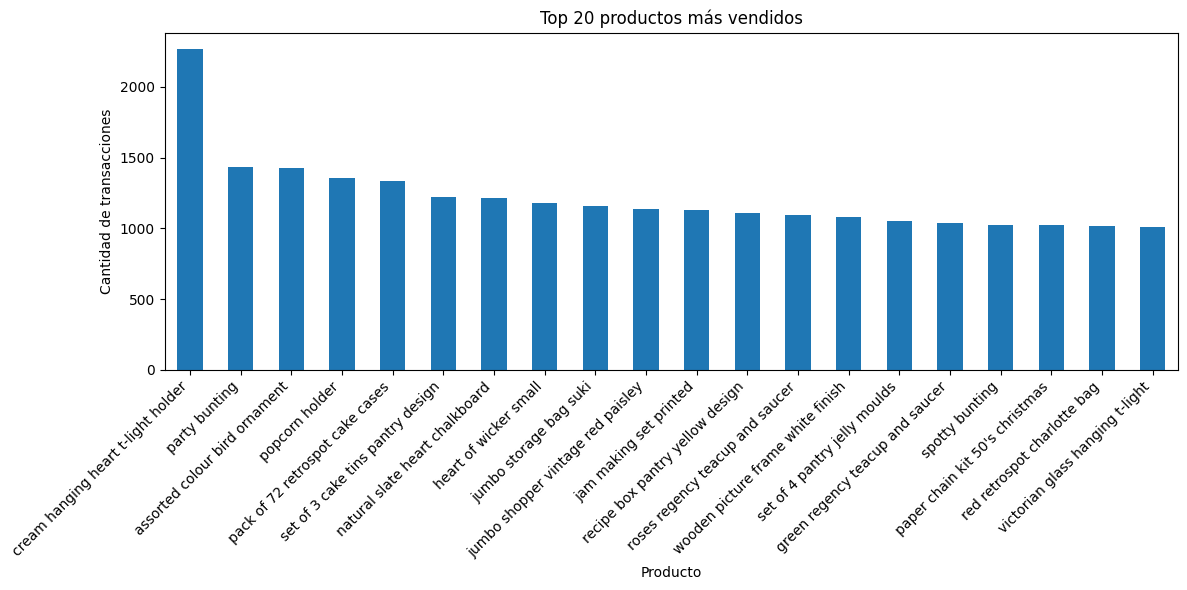

In [0]:
%python
# -----------------------------
# 3. Gráficos estáticos
# -----------------------------

# 3.1 Top 20 productos más vendidos
top_n = 20
conteo_top = pdf["producto_limpio"].value_counts().head(top_n)

plt.figure(figsize=(12,6))
conteo_top.plot(kind="bar")
plt.title(f"Top {top_n} productos más vendidos")
plt.xlabel("Producto")
plt.ylabel("Cantidad de transacciones")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



### 📊 Gráfico 2: Monto promedio por día de la semana (seaborn — categórico)
El gráfico muestra qué días generan mayores ingresos promedio, Si algunos días tienen barras más altas, indican mayor actividad comercial. Es Útil para analizar patrones semanales y planificar inventarios.

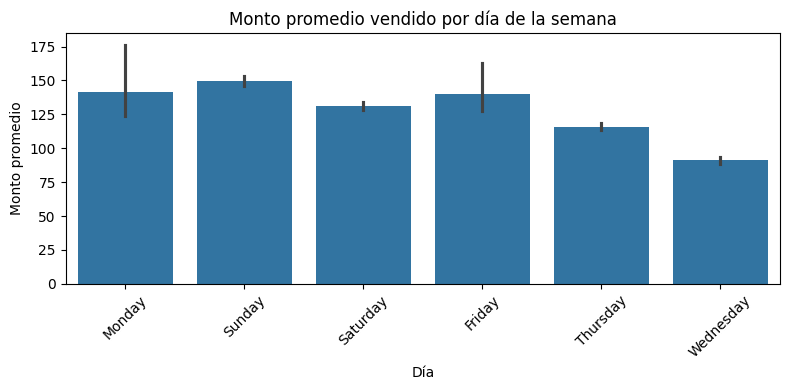

nombre_dia
Friday       140.270773
Monday       141.463297
Saturday     130.966534
Sunday       149.762142
Thursday     115.972052
Wednesday     90.983670
Name: monto, dtype: float64


In [0]:
%python
# 3.2 Monto promedio vendido por día de la semana
plt.figure(figsize=(8,4))
sns.barplot(data=pdf, x="nombre_dia", y="monto", estimator="mean")
plt.title("Monto promedio vendido por día de la semana")
plt.xlabel("Día")
plt.ylabel("Monto promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Imprimir valores exactos
print(pdf.groupby("nombre_dia")["monto"].mean())


###  📊 3. Gráfico interactivo con Plotly: Monto total mensual de los 10 productos más vendidos
Este gráfico interactivo muestra el monto total mensual por los 10 productos más vendidos, permitiendo identificar rápidamente los productos que generan más ingresos. Se agruparon los datos por mes y producto, sumando los montos de cada transacción para visualizar tendencias y comparaciones. Los colores diferencian los productos y el eje y se ajustó para que incluso las barras pequeñas sean visibles. Debajo del gráfico se imprimen los montos exactos por producto, complementando la visualización con información numérica precisa.

In [0]:
%python
import plotly.express as px
import plotly.io as pio

# Forzar renderer para Databricks/Jupyter
pio.renderers.default = "databricks"

# -----------------------------
# Filtrar productos más relevantes
# -----------------------------
# Seleccionamos, por ejemplo, los 10 productos con mayor monto total
top_productos = (
    pdf.groupby("producto_limpio")["monto"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

pdf_top = pdf[pdf["producto_limpio"].isin(top_productos)]

# -----------------------------
# Agrupar datos por mes y producto
# -----------------------------
pdf_resumen = (
    pdf_top.groupby(["mes", "producto_limpio"])["monto"]
    .sum()
    .reset_index()
    .sort_values("mes")
)

# -----------------------------
# Crear gráfico interactivo
# -----------------------------
fig = px.bar(
    pdf_resumen,
    x="mes",
    y="monto",
    color="producto_limpio",
    barmode="group",
    title="Monto total mensual por los 10 productos más vendidos",
    width=1000,
    height=500,
    color_discrete_sequence=px.colors.qualitative.Set3
)

# Recortar el eje y para resaltar mejor las barras
fig.update_yaxes(range=[0, pdf_resumen["monto"].max() * 1.1])

# Mejorar visibilidad con fondo y cuadrículas
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="#f0f0f0",
    title_font=dict(size=24, color="black"),
    xaxis=dict(title="Mes", gridcolor="lightgray", tickmode="linear"),
    yaxis=dict(title="Monto", gridcolor="lightgray"),
    legend_title_text="Producto",
)

# Mostrar gráfico interactivo
fig.show()

# -----------------------------
# Imprimir los montos totales por producto
# -----------------------------
montos_totales = pdf_top.groupby("producto_limpio")["monto"].sum().sort_values(ascending=False)
print("Montos totales por producto:")
print(montos_totales)

Montos totales por producto:
producto_limpio
paper craft little birdie             1002718.10
medium ceramic top storage jar         881200.70
world war 2 gliders asstd designs      560264.50
popcorn holder                         536271.95
cream hanging heart t-light holder     475954.17
assorted colour bird ornament          409197.02
pack of 72 retrospot cake cases        387710.47
rabbit night light                     290472.56
mini paint set vintage                 284107.98
victorian glass hanging t-light        268175.19
Name: monto, dtype: float64
